# **Titanic disaster ML modelling**

In [47]:
# Import necessary libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

# Open the training and testing datasets, and inspect the first few rows of the training dataset
train = pd.read_csv('dataset/train.csv'); test = pd.read_csv('dataset/test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The target variable `Survived` is included on the training set. On the other hand, the testing set does not include the target variable, so we need to predict it.

In [48]:
# Let's do some basic data exploration to understand the structure of the dataset and identify any missing values or anomalies. We can check the shape of the dataset, the data types of each column, and the summary statistics for numerical columns.
print("Training dataset shape:", train.shape)
print("Testing dataset shape:", test.shape)
print("\nData types in training dataset:\n", train.dtypes)
print("\nSummary statistics for numerical columns in training dataset:\n", train.describe())

Training dataset shape: (891, 12)
Testing dataset shape: (418, 11)

Data types in training dataset:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Summary statistics for numerical columns in training dataset:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000 

In [49]:
# the target variable is included on the training dataset, but not on the testing dataset. We can check for missing values in the training dataset to see if there are any gaps in the data that we need to address before building our model.
print("\nMissing values in training dataset:\n", train.isnull().sum())


Missing values in training dataset:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Let's define the target variable and the features for our model. The target variable is typically the column we want to predict, while the features are the columns that we will use to make our predictions.
target = train['Survived']
train  = train.drop('Survived', axis=1)  # Assuming 'Survived' is the target variable

There are plenty of missing values on the `Cabin` feature, so it is better to drop it rhater than imputing the most common value (median). Further on, we can check if that variable presents high correlation with the target variable.

In [58]:
train, test = train.drop('Cabin', axis=1), test.drop('Cabin', axis=1)

For the `Age` feature, we can impute the most probable value (median), as we have 177 observations with null values and we don't want to delete the entire column as it may present an important correlation with the target variable `Survived`.

In [63]:
train.Age.fillna(train.Age.median(), inplace=True)  # Fill missing values in 'Age' with the median age
test.Age.fillna(test.Age.median(), inplace=True)    # Fill missing values in 'Age' with the median age

/tmp/ipykernel_13927/4122061206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Age.fillna(train.Age.median(), inplace=True)  # Fill missing values in 'Age' with the median age
/tmp/ipykernel_13927/4122061206.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

We proceed in a similar way for the 'Embarked' column, filling missing values with the most frequent value (mode) in that column.


In [67]:
train.Embarked.fillna(train.Embarked.mode()[0], inplace=True)  # Fill missing values in 'Embarked' with the most frequent value
test.Embarked.fillna(test.Embarked.mode()[0], inplace=True)    # Fill missing values in 'Embarked' with the most frequent value

/tmp/ipykernel_13927/3542603794.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test.Embarked.fillna(test.Embarked.mode()[0], inplace=True)    # Fill missing values in 'Embarked' with the most frequent value


/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data


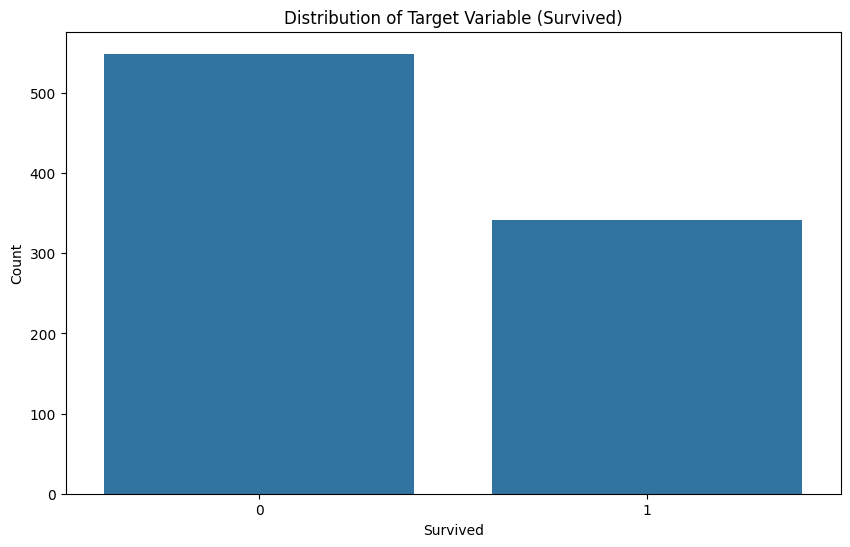

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Survived', data=pd.concat([train, target], axis=1))
plt.title('Distribution of Target Variable (Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()